In [1]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization, SpatialDropout1D, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
file_path = r"D:\AI and Data Science- Loyalist College\Term 3\NLP\Assignment 2\Sentiment_Data\Sentiment_Data.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1").dropna(subset=['Tweet'])

# Balance dataset: Ensure class balance by sampling 10,000 per class
df_sample = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(min(len(x), 6000), random_state=42))

# Text Cleaning Function (Handling Hashtags, Emojis)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)  # Remove hashtags but keep words
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters, emojis, and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply text cleaning
df_sample['Clean_Tweet'] = df_sample['Tweet'].apply(clean_text)

# Encode labels
label_encoder = LabelEncoder()
df_sample['Sentiment'] = label_encoder.fit_transform(df_sample['Sentiment'])
num_classes = len(label_encoder.classes_)

# Train-Test Split (80-20)
train_df, test_df = train_test_split(df_sample, test_size=0.2, stratify=df_sample['Sentiment'], random_state=42)

# Tokenization settings
MAX_NUM_WORDS = 30000  # Vocabulary size
MAX_SEQUENCE_LENGTH = 120  # Limit tweet length
EMBEDDING_DIM = 200  # GloVe embedding size

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['Clean_Tweet'])

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['Clean_Tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['Clean_Tweet'])

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='pre')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='pre')


In [3]:
# One-hot encode labels
y_train = to_categorical(train_df['Sentiment'], num_classes=num_classes)
y_test = to_categorical(test_df['Sentiment'], num_classes=num_classes)

# Load GloVe embeddings
embedding_index = {}
glove_file_path = r"D:\AI and Data Science- Loyalist College\Term 3\NLP\glove.6B.200d.txt"

with open(glove_file_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        embedding_index[word] = np.array(values[1:], dtype='float32')

# Create embedding matrix
embedding_matrix = np.zeros((MAX_NUM_WORDS, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_NUM_WORDS:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


In [4]:
# Define Model
EMBEDDING_DIM = 200  

model = Sequential([
    # Learnable Embedding Layer
    Embedding(input_dim=MAX_NUM_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH, trainable=True),

    SpatialDropout1D(0.4),  # Prevent overfitting

    # First Bidirectional LSTM Layer
    Bidirectional(LSTM(128, return_sequences=True, activation='tanh')),
    Dropout(0.4),

    # Second Bidirectional LSTM Layer
    Bidirectional(LSTM(64, return_sequences=True, activation='tanh')),
    Dropout(0.4),

    # Third LSTM Layer
    LSTM(32, activation='tanh'),
    Dropout(0.3),

    # Fully Connected Layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

# Compile Model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Build Model Properly
model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

# Model Summary
model.summary()


C:\Users\dhrjd\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 120, 200)            │       6,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 120, 200)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 120, 256)            │         336,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 120, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 120, 128)            │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 120, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,523,205 (24.88 MB)

 Trainable params: 6,523,141 (24.88 MB)

 Non-trainable params: 64 (256.00 B)

In [6]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

In [7]:
history = model.fit(
    X_train_padded, y_train, 
    validation_data=(X_test_padded, y_test),
    epochs=15, batch_size=64, 
    callbacks=[early_stopping, reduce_lr], 
    verbose=2
)


Epoch 1/15
375/375 - 513s - 1s/step - accuracy: 0.3584 - loss: 1.4611 - val_accuracy: 0.4233 - val_loss: 1.4420 - learning_rate: 0.0010
Epoch 2/15
375/375 - 486s - 1s/step - accuracy: 0.5126 - loss: 1.1896 - val_accuracy: 0.4942 - val_loss: 1.2223 - learning_rate: 0.0010
Epoch 3/15
375/375 - 479s - 1s/step - accuracy: 0.6285 - loss: 0.9658 - val_accuracy: 0.5098 - val_loss: 1.2558 - learning_rate: 0.0010
Epoch 4/15
375/375 - 495s - 1s/step - accuracy: 0.7130 - loss: 0.7831 - val_accuracy: 0.4933 - val_loss: 1.3299 - learning_rate: 0.0010
Epoch 5/15
375/375 - 543s - 1s/step - accuracy: 0.7747 - loss: 0.6408 - val_accuracy: 0.5147 - val_loss: 1.4559 - learning_rate: 0.0010
Epoch 6/15
375/375 - 558s - 1s/step - accuracy: 0.8488 - loss: 0.4593 - val_accuracy: 0.5160 - val_loss: 1.5655 - learning_rate: 5.0000e-04
Epoch 7/15
375/375 - 568s - 2s/step - accuracy: 0.8836 - loss: 0.3627 - val_accuracy: 0.5175 - val_loss: 1.7131 - learning_rate: 5.0000e-04


188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 207ms/step


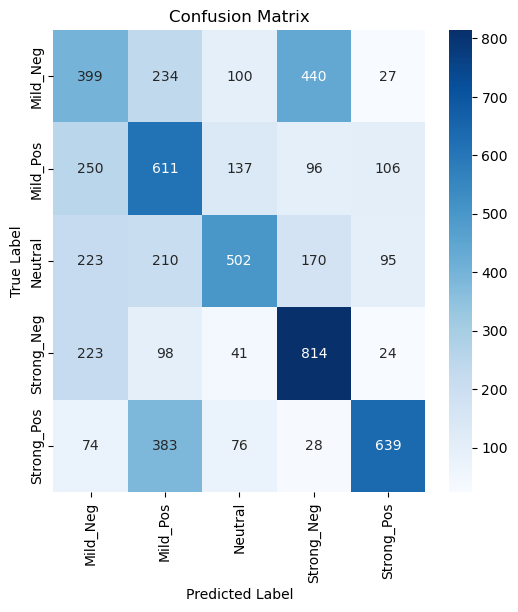

In [8]:
# Predict on test data
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Classification Report
print(classification_report(y_test_classes, y_pred_classes, target_names=label_encoder.classes_))

# AUC Score
auc_score = roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f"AUC Score: {auc_score:.4f}")


              precision    recall  f1-score   support

    Mild_Neg       0.34      0.33      0.34      1200
    Mild_Pos       0.40      0.51      0.45      1200
     Neutral       0.59      0.42      0.49      1200
  Strong_Neg       0.53      0.68      0.59      1200
  Strong_Pos       0.72      0.53      0.61      1200

    accuracy                           0.49      6000
   macro avg       0.51      0.49      0.50      6000
weighted avg       0.51      0.49      0.50      6000

AUC Score: 0.7926


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []

for train_index, val_index in skf.split(X_train_padded, np.argmax(y_train, axis=1)):
    X_train_fold, X_val_fold = X_train_padded[train_index], X_train_padded[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold),
              epochs=5, batch_size=64, verbose=0)  # Small epochs for CV
    
    fold_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)[1]
    cv_accuracies.append(fold_accuracy)

print(f"Cross-Validation Accuracies: {cv_accuracies}")
print(f"Mean CV Accuracy: {np.mean(cv_accuracies):.4f}")


Cross-Validation Accuracies: [0.637708306312561, 0.8427083492279053, 0.9120833277702332, 0.9439583420753479, 0.96895831823349]
Mean CV Accuracy: 0.8611
